# 1 · Where is Mars tonight?

The question sounds simple and the answer is not a lookup. This notebook goes from a
date to a position in three dimensions, deriving each step and checking it before
moving on.

The whole chain is four steps:

1. **Propagate the orbital elements** to the date you care about.
2. **Solve Kepler's equation** — the only genuinely hard part, because it has no
   closed-form solution.
3. **Place the planet on a flat ellipse.**
4. **Rotate that ellipse into 3D.**

Everything here uses [`orrery`](https://github.com/DanielRamon10/orrery-lab), but the
point is to show the working rather than to call the library, so the intermediate
quantities are all exposed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from orrery import PLANETS, body_state, julian_date, solve_kepler
from orrery.constants import GM_SUN
from orrery.kepler import true_anomaly_from_eccentric

plt.rcParams.update({
    "figure.facecolor": "white", "axes.grid": True,
    "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7",
    "font.size": 9,
})
BLUE, ORANGE = "#2a78d6", "#eb6834"

## Step 0 — six numbers describe an orbit

An orbit is fully specified by six quantities. Three fix the shape and size, three fix
its orientation and where the planet is along it.

| | |
|---|---|
| $a$ | semi-major axis — the size of the ellipse |
| $e$ | eccentricity — how squashed it is (0 is a circle) |
| $i$ | inclination — tilt away from Earth's orbital plane |
| $\Omega$ | longitude of the ascending node — where the orbit crosses upward |
| $\varpi$ | longitude of perihelion — the direction of closest approach |
| $L$ | mean longitude — where the planet is *right now* |

Only the last one changes quickly. The others drift slowly, because the planets pull
on each other, so the table stores each element **and its rate of change per century**.

In [2]:
mars = PLANETS["mars"]
print(f"Mars at J2000")
print(f"  a  = {mars.semi_major_axis_au:.6f} AU      rate {mars.semi_major_axis_rate:+.8f} /century")
print(f"  e  = {mars.eccentricity:.6f}          rate {mars.eccentricity_rate:+.8f}")
print(f"  i  = {mars.inclination_deg:.6f} deg      rate {mars.inclination_rate:+.8f}")
print()
print(f"  perihelion {mars.perihelion_au:.4f} AU   aphelion {mars.aphelion_au:.4f} AU")
print(f"  period     {mars.period_days:.2f} days = {mars.period_days / 365.25:.3f} years")

Mars at J2000
  a  = 1.523710 AU      rate +0.00001847 /century
  e  = 0.093394          rate +0.00007882
  i  = 1.849691 deg      rate -0.00813131

  perihelion 1.3814 AU   aphelion 1.6660 AU
  period     686.99 days = 1.881 years


## Step 1 — the mean anomaly grows perfectly linearly

Time enters through the **mean anomaly** $M$: an imaginary angle that increases at a
constant rate, as if the planet moved in a circle at uniform speed.

$$M = n\,(t - t_{\text{peri}}), \qquad n = \sqrt{\frac{GM}{a^3}}$$

That is a fiction, but a useful one. The planet does *not* move uniformly — it races
through perihelion and crawls through aphelion, which is Kepler's second law. So $M$ is
easy to compute and is not where the planet is.

In [3]:
jd = julian_date(2026, 12, 25)
elements = mars.at(jd)

print(f"Mars on 2026-12-25  (JD {jd})")
for key, value in elements.items():
    unit = "AU" if key == "a" else ("" if key == "e" else "rad")
    print(f"  {key:<6} {float(value):+.6f} {unit}")

# M comes out as ~90 radians: it has been accumulating since J2000 and is not wrapped.
# Only its value modulo a full turn means anything physically.
revolutions = float(elements["M"]) / (2 * np.pi)
print()
print(f"  M is unwrapped: {revolutions:.2f} revolutions since J2000,")
print(f"  which is {float(elements['M']) % (2 * np.pi):.4f} rad "
      f"= {np.degrees(float(elements['M'])) % 360:.2f} deg around the current orbit.")

Mars on 2026-12-25  (JD 2461399.5)
  a      +1.523715 AU
  e      +0.093415 
  i      +0.032245 rad
  Omega  +0.863599 rad
  omega  -1.279402 rad
  M      +90.466572 rad

  M is unwrapped: 14.40 revolutions since J2000,
  which is 2.5020 rad = 143.35 deg around the current orbit.


## Step 2 — Kepler's equation, and why it is hard

To get from the fictional uniform angle $M$ to a real position, we need the
**eccentric anomaly** $E$, an angle with actual geometric meaning on the ellipse. The
bridge between them is Kepler's equation:

$$M = E - e\sin E$$

This is **transcendental**: $E$ appears both alone and inside a sine, and no
rearrangement isolates it. There is no formula. It has to be solved numerically, and it
has been solved numerically since 1650.

Newton–Raphson converges quadratically here:

$$E_{k+1} = E_k - \frac{E_k - e\sin E_k - M}{1 - e\cos E_k}$$

Let us watch it converge.

In [4]:
def newton_trace(mean_anomaly, eccentricity, steps=6):
    """Newton-Raphson on Kepler's equation, returning every iterate."""
    # Danby's starting guess: much better than E = M once the orbit is eccentric.
    eccentric = mean_anomaly + np.sign(np.sin(mean_anomaly)) * 0.85 * eccentricity
    trace = [eccentric]
    for _ in range(steps):
        residual = eccentric - eccentricity * np.sin(eccentric) - mean_anomaly
        eccentric = eccentric - residual / (1 - eccentricity * np.cos(eccentric))
        trace.append(eccentric)
    return np.array(trace)

M = 1.0
for label, e in [("Mars-like", 0.093), ("Mercury-like", 0.206), ("comet-like", 0.95)]:
    trace = newton_trace(M, e)
    residuals = np.abs(trace - e * np.sin(trace) - M)
    print(f"{label:<14} e = {e:.3f}")
    for step, residual in enumerate(residuals):
        print(f"    iteration {step}:  |residual| = {residual:.3e}")
    print()

Mars-like      e = 0.093
    iteration 0:  |residual| = 2.930e-03
    iteration 1:  |residual| = 3.853e-07
    iteration 2:  |residual| = 6.661e-15
    iteration 3:  |residual| = 0.000e+00
    iteration 4:  |residual| = 0.000e+00
    iteration 5:  |residual| = 0.000e+00
    iteration 6:  |residual| = 0.000e+00

Mercury-like   e = 0.206
    iteration 0:  |residual| = 1.498e-02
    iteration 1:  |residual| = 2.523e-05
    iteration 2:  |residual| = 7.137e-11
    iteration 3:  |residual| = 0.000e+00
    iteration 4:  |residual| = 0.000e+00
    iteration 5:  |residual| = 0.000e+00
    iteration 6:  |residual| = 0.000e+00

comet-like     e = 0.950
    iteration 0:  |residual| = 1.160e-01
    iteration 1:  |residual| = 4.122e-03
    iteration 2:  |residual| = 4.452e-06
    iteration 3:  |residual| = 5.222e-12
    iteration 4:  |residual| = 0.000e+00
    iteration 5:  |residual| = 0.000e+00
    iteration 6:  |residual| = 0.000e+00



Three or four iterations reach machine precision even at $e = 0.95$. Each step roughly
*squares* the error — that is what quadratic convergence means, and it is why nobody
worries about the lack of a closed form.

The library's solver adds a safety net: for extreme eccentricities Newton can overshoot,
so any element that fails to converge falls back to bisection. That fallback cannot
fail, because rearranging the equation to $E = M + e\sin E$ shows the root is always
trapped inside $[M - e,\; M + e]$.

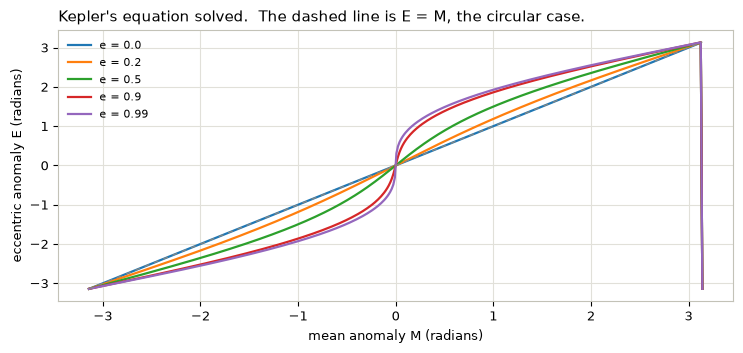

In [5]:
# Residual across the full grid the library is tested on.
mean_grid = np.linspace(-np.pi, np.pi, 400)
fig, ax = plt.subplots(figsize=(7.5, 3.6))

for e in [0.0, 0.2, 0.5, 0.9, 0.99]:
    eccentric = solve_kepler(mean_grid, e)
    ax.plot(mean_grid, eccentric, linewidth=1.6, label=f"e = {e}")

ax.plot(mean_grid, mean_grid, color="#898781", linewidth=0.9, linestyle=(0, (4, 4)))
ax.set_xlabel("mean anomaly M (radians)")
ax.set_ylabel("eccentric anomaly E (radians)")
ax.set_title("Kepler's equation solved.  The dashed line is E = M, the circular case.", loc="left")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## Step 3 — from the eccentric anomaly to a real position

With $E$ in hand the geometry is straightforward. In the **perifocal frame** — a flat
2D frame with the Sun at the origin and the x-axis pointing at perihelion:

$$x' = a(\cos E - e), \qquad y' = a\sqrt{1-e^2}\,\sin E$$

The **true anomaly** $\nu$ is the angle actually subtended at the Sun — what you would
measure with a telescope. Comparing the three angles shows Kepler's second law directly.

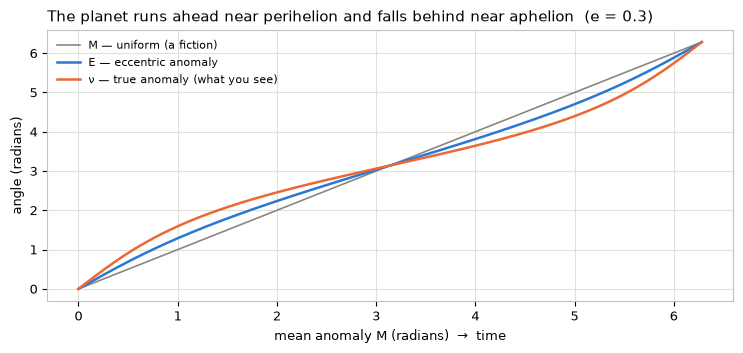

Maximum lead of the true anomaly over the uniform one: 34.75 degrees


In [6]:
mean_anomalies = np.linspace(0, 2 * np.pi, 400)
eccentricity = 0.3
eccentric = solve_kepler(mean_anomalies, eccentricity)
true = np.unwrap(true_anomaly_from_eccentric(eccentric, eccentricity))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(mean_anomalies, mean_anomalies, color="#898781", linewidth=1.2, label="M — uniform (a fiction)")
ax.plot(mean_anomalies, np.unwrap(eccentric), color=BLUE, linewidth=1.8, label="E — eccentric anomaly")
ax.plot(mean_anomalies, true, color=ORANGE, linewidth=1.8, label="ν — true anomaly (what you see)")

ax.set_xlabel("mean anomaly M (radians)  →  time")
ax.set_ylabel("angle (radians)")
ax.set_title(f"The planet runs ahead near perihelion and falls behind near aphelion  (e = {eccentricity})", loc="left")
ax.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

lead = np.degrees(true - mean_anomalies)
print(f"Maximum lead of the true anomaly over the uniform one: {lead.max():.2f} degrees")

That gap is Kepler's second law made visible. A planet on an eccentric orbit is
sometimes tens of degrees ahead of where uniform motion would put it — for Mars, enough
to be the difference between a successful launch window and a miss.

## Step 4 — tilting the ellipse into three dimensions

The flat ellipse becomes a real orbit with three rotations:

$$R = R_z(\Omega)\, R_x(i)\, R_z(\omega)$$

reading right to left: spin the ellipse within its own plane so perihelion points the
right way, tip the plane by the inclination, then swing it around to the ascending node.

The same matrix rotates **velocity** as well as position, so differentiating the
perifocal coordinates gives full state vectors for free — which is exactly what an
N-body integrator needs as a starting condition.

In [7]:
state = body_state("mars", jd)

print("Mars on 2026-12-25, heliocentric ecliptic J2000")
print(f"  position  {np.array2string(state.position, precision=6)}  AU")
print(f"  velocity  {np.array2string(state.velocity, precision=8)}  AU/day")
print(f"  distance  {float(state.distance_au):.6f} AU")
print(f"  speed     {float(state.speed_km_per_s):.3f} km/s")

Mars on 2026-12-25, heliocentric ecliptic J2000
  position  [-0.949701  1.338706  0.051342]  AU
  velocity  [-0.01088536 -0.00690527  0.0001222 ]  AU/day
  distance  1.642163 AU
  speed     22.321 km/s


## Checking it, without a table of expected answers

The interesting question is how you know any of this is right. Comparing against a
saved array only proves the code has not changed. Physical laws are stronger, because a
plausible-but-wrong answer cannot satisfy them.

**Kepler's second law** says the specific angular momentum $\mathbf{h} = \mathbf{r}
\times \mathbf{v}$ is constant. **Vis-viva** relates speed to distance at every point:

$$v^2 = GM\left(\frac{2}{r} - \frac{1}{a}\right)$$

In [8]:
elements = PLANETS["mars"].at(jd)
sweep = np.linspace(0, 2 * np.pi, 200)

from orrery.ephemeris import state_from_elements
orbit = state_from_elements(
    elements["a"], elements["e"], elements["i"],
    elements["Omega"], elements["omega"], sweep,
)

h = orbit.specific_angular_momentum
h_magnitude = np.linalg.norm(h, axis=-1)
h_expected = np.sqrt(GM_SUN * elements["a"] * (1 - elements["e"] ** 2))

speed_squared = orbit.speed_au_per_day ** 2
vis_viva = GM_SUN * (2 / orbit.distance_au - 1 / elements["a"])

print("Around one full orbit of Mars:")
print(f"  |h| varies by      {np.ptp(h_magnitude) / h_magnitude.mean():.3e}  (relative)")
print(f"  |h| vs closed form {abs(h_magnitude.mean() - float(h_expected)) / float(h_expected):.3e}")
print(f"  vis-viva residual  {np.max(np.abs(speed_squared / vis_viva - 1)):.3e}")
print()
print("All at floating-point round-off. Nothing here was fitted to make that happen.")

Around one full orbit of Mars:
  |h| varies by      8.205e-16  (relative)
  |h| vs closed form 0.000e+00
  vis-viva residual  9.992e-16

All at floating-point round-off. Nothing here was fitted to make that happen.


## And one check against the outside world

Conservation laws confirm internal consistency. They would still hold if the whole
orbit were rotated to the wrong place in the sky. So the last check uses a number that
does not come from this code at all: on 1 January 2000, Earth was **0.9833 AU** from
the Sun, and the Sun sat at ecliptic longitude **280.4°**.

In [9]:
from orrery.constants import J2000_JD

earth = body_state("earth", J2000_JD)
x, y, _ = earth.position
earth_longitude = np.degrees(np.arctan2(y, x)) % 360
sun_longitude = (earth_longitude + 180) % 360

print(f"Earth–Sun distance at J2000   computed {float(earth.distance_au):.4f} AU   published 0.9833 AU")
print(f"Sun's ecliptic longitude      computed {sun_longitude:.1f}°       published 280.4°")
print()

# Earth reaches perihelion in early January, not at the December solstice.
days = julian_date(2026, 1, 1) + np.arange(365.0)
distance = body_state("earth", days).distance_au
print(f"Earth's perihelion falls {int(np.argmin(distance))} days into 2026  (published: 2–5 January)")
print(f"Earth's aphelion falls  {int(np.argmax(distance))} days into 2026  (published: ~4 July)")

Earth–Sun distance at J2000   computed 0.9833 AU   published 0.9833 AU
Sun's ecliptic longitude      computed 280.4°       published 280.4°

Earth's perihelion falls 3 days into 2026  (published: 2–5 January)
Earth's aphelion falls  185 days into 2026  (published: ~4 July)


## What this buys

Four steps, none of them a lookup, and the result agrees with published values while
satisfying the conservation laws exactly. Everything else in the project stands on this:
the browser scene solves the same equation every animation frame, the N-body integrator
takes these state vectors as its starting conditions, and the statistics are computed
from these positions.

**Next:** [2 · Why the integrator matters more than its accuracy](02-why-integrators-matter.ipynb),
where the two-body problem gives way to the N-body one and the choice of numerical
method turns out to matter more than its advertised order.